## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
AUTHOR  = 'A.Anand '                                                            
FIT     = 'NMF     '                                                            
SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 
TGTQSO  = 'DESI DR1'                                                            

In [3]:
hdul.close()

### Running qsoabsfind as bash script:

In [4]:
# #!/bin/bash

# # Loop over absorber types
# for absorber in MgII CIV; do
#   echo "Running qsoabsfind for $absorber..."

#   qsoabsfind \
#     --input-fits-file ../data/desi/qso_test_spectra.fits \
#     --absorber ${absorber} \
#     --output ../data/desi/${absorber}_cat.fits \
#     --headers AUTHOR=A.Anand SURVEY=DESI DR=1 \
#     --ncpus 8 \
#     --coldens \
#     --dv 300 \
#     --constant-file ../data/desi/desi_constants.py \
#     >> ../data/desi/logs/${absorber}.log

#   echo "Finished $absorber"
# done


- I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits` and `../data/desi/CIV_cat.fits`. Corresponding Log files are also saved.

### Exploring output

Text(0.5, 0, 'MgII redshift')

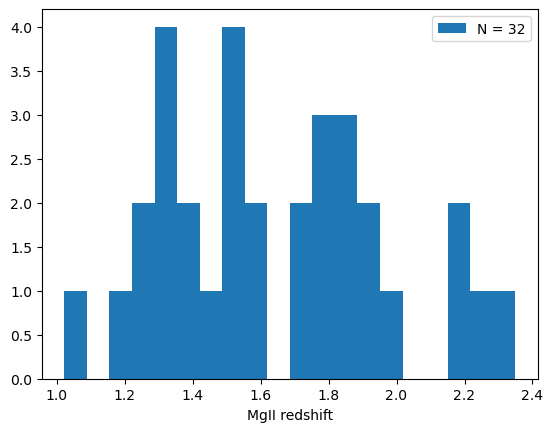

In [5]:
mgii_tab = Table.read(f'../data/desi/MgII_cat.fits', hdu=1)
zabs = mgii_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

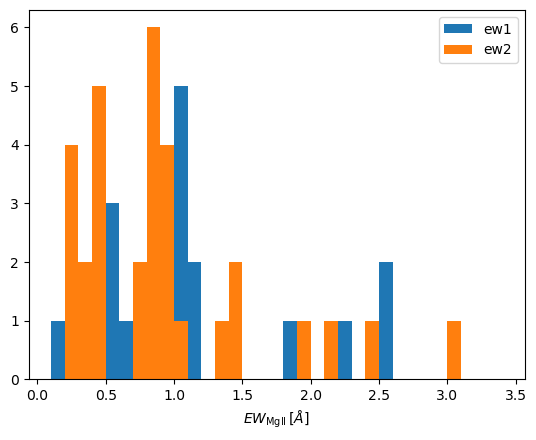

In [6]:
ew1 = mgii_tab["MGII_2796_EW"].data
ew2 = mgii_tab["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 46...
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds



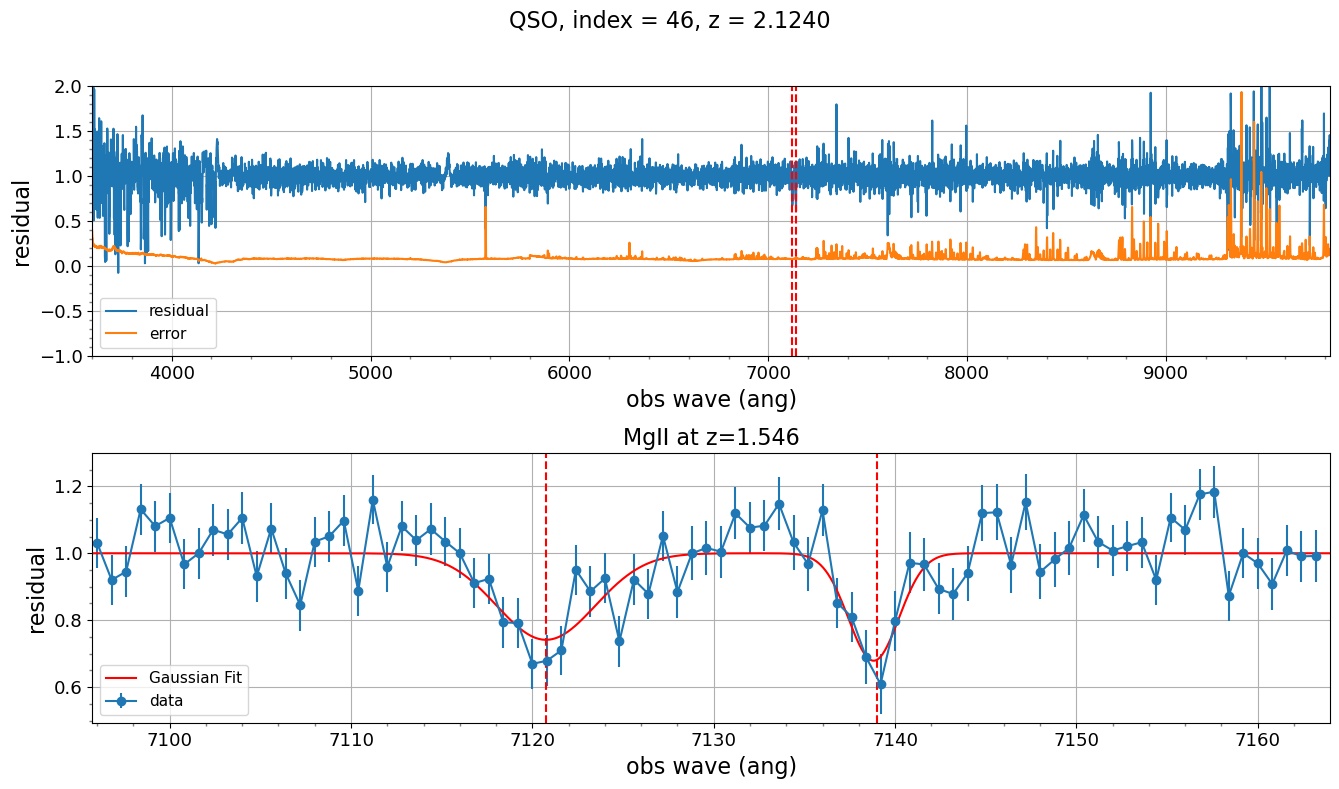

In [7]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab[mgii_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [8]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.constants import search_parameters
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., 'MgII', 'CIV').
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
        tuple: Contains li

In [9]:
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', 42, 'MgII', **search_parameters["MgII"])

INFO: Starting search for QSO INDEX = 42
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.01 seconds



KeyError: 'dz_start'

In [ ]:
abs_tab = Table.read(f'../data/desi/CIV_cat.fits', hdu=1)
zabs = abs_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

In [ ]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(abs_tab["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
# select corresponding zabs table
zabs = abs_tab[abs_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)